# Density-based Spatial Clustering of applications with noise

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
blobs=pd.read_csv("../../jupyter_notebooks/DATA/cluster_blobs.csv")
blobs.head()

,X1,X2
0,4.645333,6.822294
1,4.784032,6.422883
2,-5.851786,5.774331
3,-7.459592,6.456415
4,4.918911,6.961479


<Axes: xlabel='X1', ylabel='X2'>

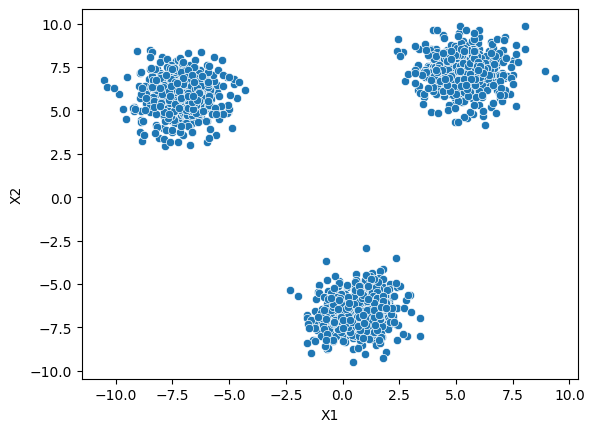

In [3]:
 sns.scatterplot(data=blobs, x='X1', y='X2')

In [4]:
moons=pd.read_csv('../../jupyter_notebooks/DATA/cluster_moons.csv')
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


<Axes: xlabel='X1', ylabel='X2'>

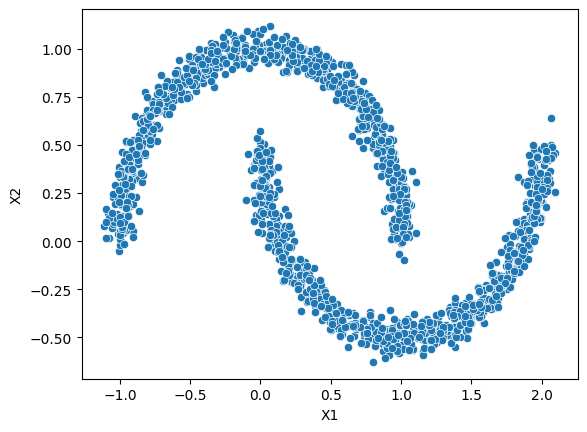

In [5]:
sns.scatterplot(data=moons, x='X1', y='X2')

In [6]:
circles=pd.read_csv('../../jupyter_notebooks/DATA/cluster_circles.csv')
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


<Axes: xlabel='X1', ylabel='X2'>

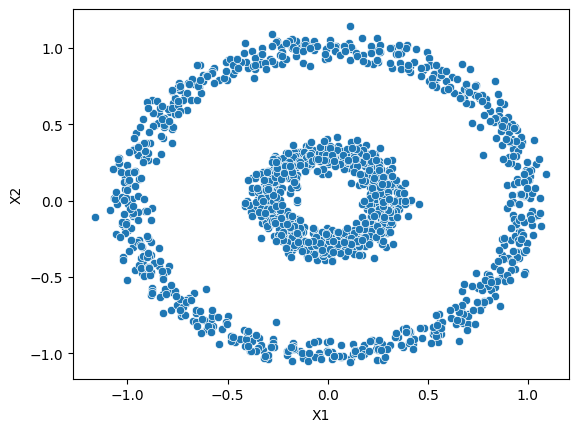

In [7]:
sns.scatterplot(data=circles,x='X1',y='X2')

In [8]:
def display_categories(model,data):
    labels=model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [9]:
from sklearn.cluster import KMeans

In [10]:
model = KMeans(n_clusters=3)

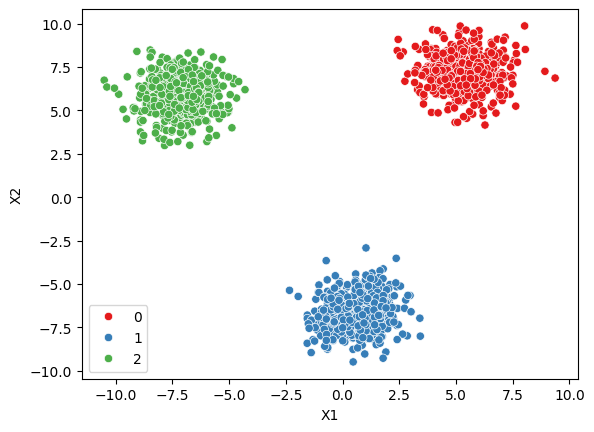

In [11]:
display_categories(model,blobs)

In [12]:
model=KMeans(n_clusters=2)

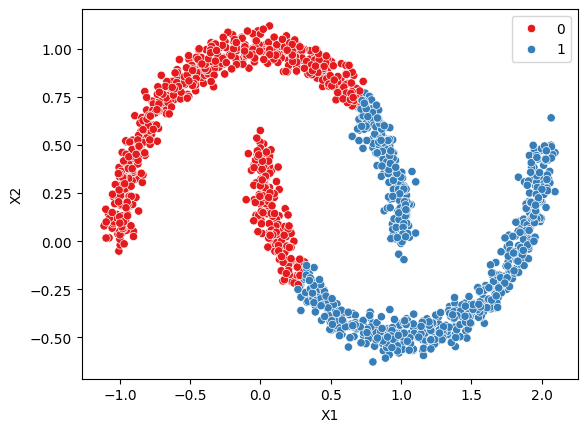

In [13]:
 display_categories(model,moons)

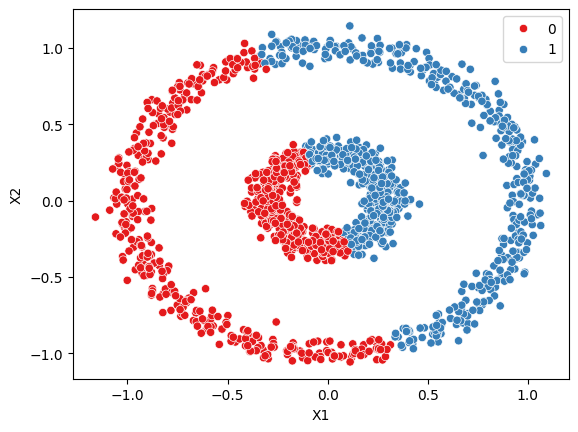

In [14]:
display_categories(model,circles)

In [15]:
from sklearn.cluster import DBSCAN

In [16]:
model=DBSCAN()

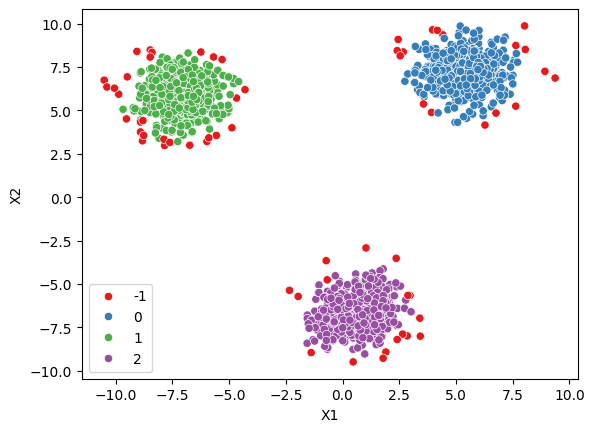

In [17]:
display_categories(model,blobs)

Assigned label '-1' is the one that DBSCAN uses for outliers. Later on, we will see how we can modify the model to not create so many outliers, since we clearly see they should be part of the clusters.

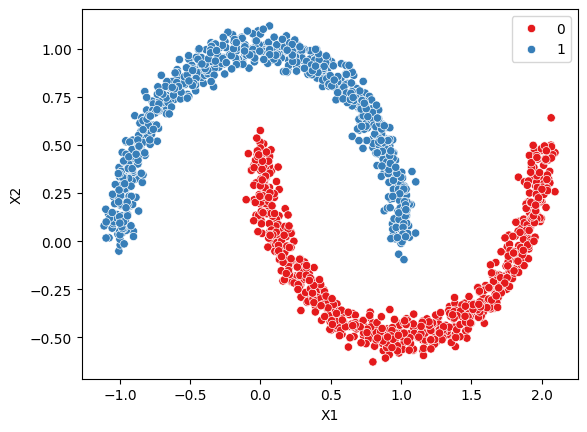

In [18]:
model=DBSCAN(eps=0.15)
display_categories(model,moons)

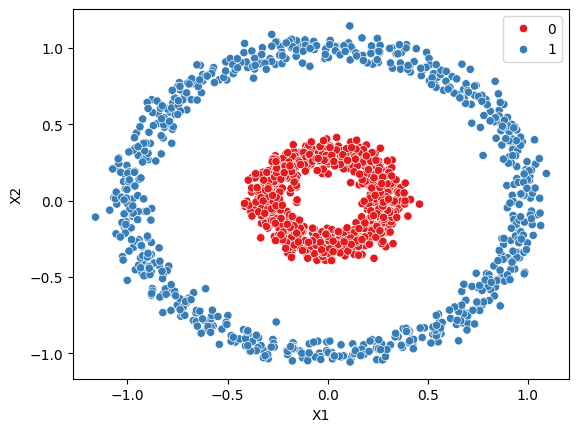

In [19]:
display_categories(model,circles)

## Adjusting Epsilon and number of outliers
We will typically use elbow/knee plotting method to adjust the number of clusters and the outliers. This will depend on the domain knowledge, so it will be best to have outliers sometimes and other times to have them in their own clusters even with one single point in them.

In [21]:
two_blobs=pd.read_csv('../../jupyter_notebooks/DATA/cluster_two_blobs.csv')
two_blobs_outliers=pd.read_csv('../../jupyter_notebooks/DATA/cluster_two_blobs_outliers.csv')

In [22]:
two_blobs.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


<Axes: xlabel='X1', ylabel='X2'>

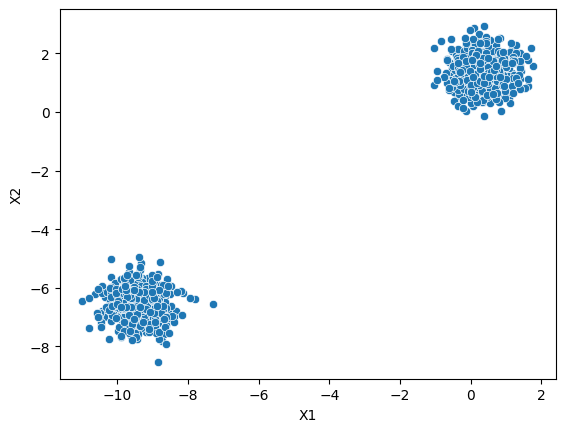

In [23]:
sns.scatterplot(data=two_blobs,x='X1',y='X2')

In [24]:
two_blobs_outliers.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


<Axes: xlabel='X1', ylabel='X2'>

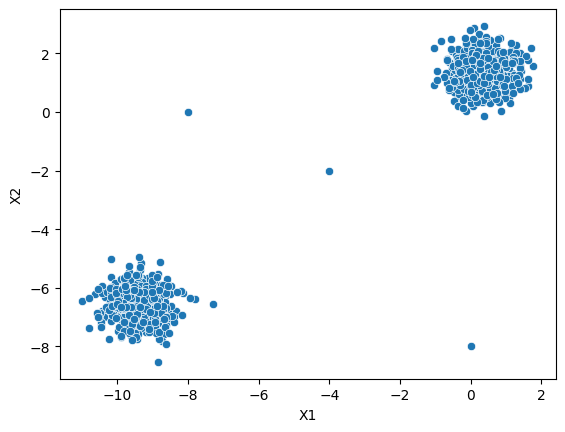

In [25]:
sns.scatterplot(data=two_blobs_outliers,x='X1',y='X2')

# Label discovery

In [26]:
def display_categories(model,data):
    labels=model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [27]:
dbscan=DBSCAN()

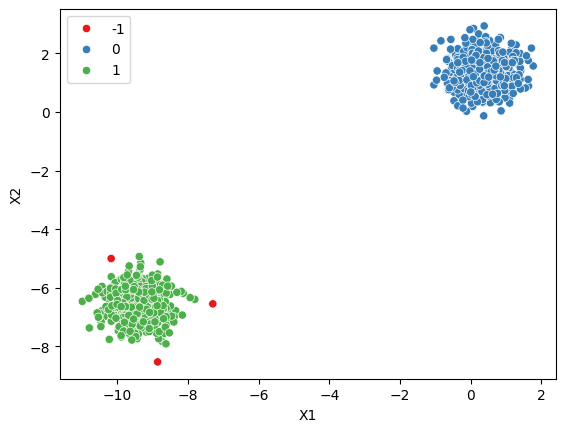

In [28]:
display_categories(dbscan,two_blobs)

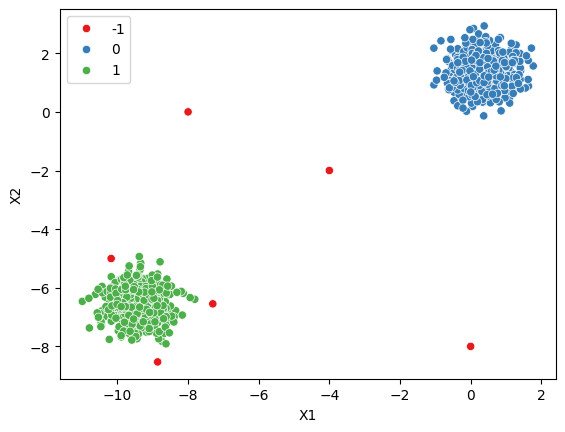

In [29]:
display_categories(dbscan,two_blobs_outliers)

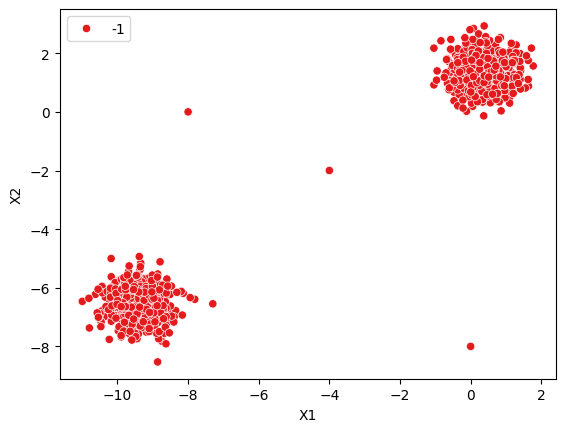

In [30]:
# Everything outlier
dbscan_min=DBSCAN(eps=0.001)
display_categories(dbscan_min,two_blobs_outliers)

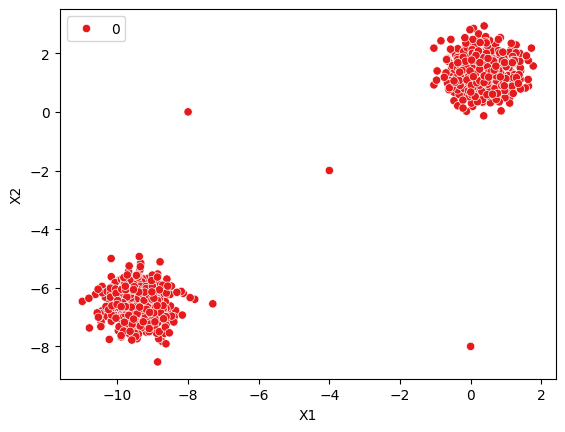

In [35]:
# Everything same cluster
dbscan_min=DBSCAN(eps=10)
display_categories(dbscan_min,two_blobs_outliers)

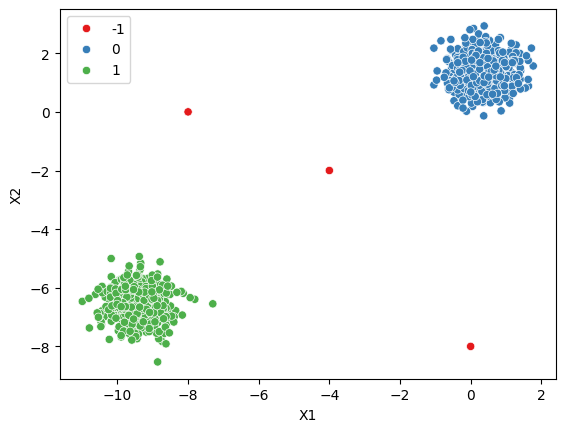

In [36]:
# Just 3 outliers
dbscan_max=DBSCAN(eps=1)
display_categories(dbscan_max,two_blobs_outliers)

In [33]:
dbscan.labels_

array([ 0,  1,  0, ..., -1, -1, -1], shape=(1003,))

In [42]:
#number of clusters
len(np.unique(dbscan_max.labels_))

3

In [37]:
#how many in "outlier" cluster
np.sum(dbscan_max.labels_==-1)

np.int64(3)

This is useful to find the rigth hyperparameters, when you have an idea of how many outliers or what percentage of outliers there should be.

This is what we will use for plotting the progress and find the best values for the hyperparameters.

In [38]:
#percentage of outliers
100*np.sum(dbscan_max.labels_==-1)/len(dbscan_max.labels_)

np.float64(0.29910269192422734)

In [39]:
len(dbscan_max.labels_)

1003

In [48]:
outlier_percent=[]
number_of_outliers=[]
for eps in np.linspace(0.001,7,200):
    dbscan=DBSCAN(eps=eps)
    dbscan.fit(two_blobs_outliers)
    #total outliers found
    number_of_outliers.append(np.sum(dbscan.labels_==-1))
    #percent of points classified as outliers
    perc_outliers=100*np.sum(dbscan.labels_==-1)/len(dbscan.labels_)
    outlier_percent.append(perc_outliers)

<Axes: >

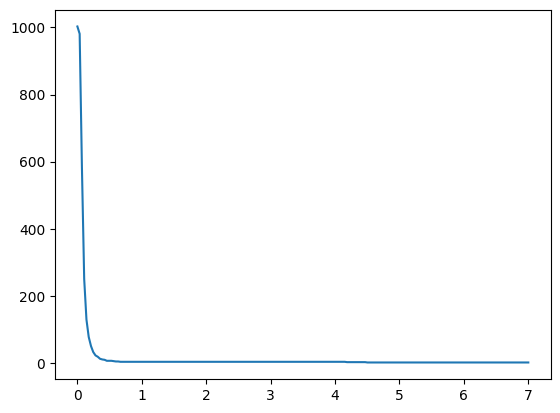

In [49]:
sns.lineplot(x=np.linspace(0.001,7,200),y=number_of_outliers)

You need to zoom in in the elbow to actually see at what value the curve is changing 

(0.0, 2.0)

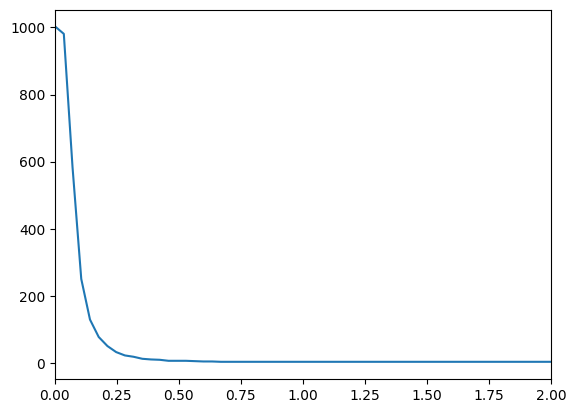

In [50]:
sns.lineplot(x=np.linspace(0.001,7,200),y=number_of_outliers)
plt.xlim(0,2)

Let's zoom in to see when the number of outliers hits the expected number 3

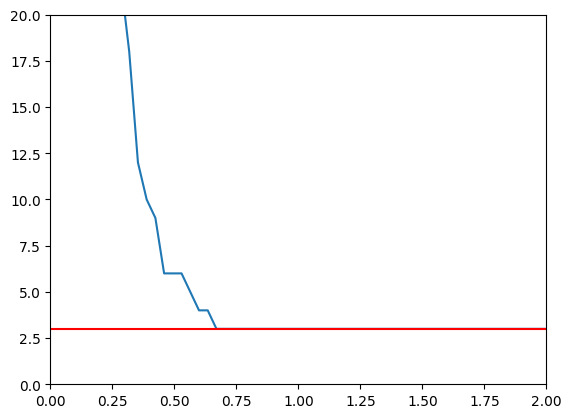

In [52]:
sns.lineplot(x=np.linspace(0.001,7,200),y=number_of_outliers)
plt.xlim(0,2)
plt.ylim(0,20)
# let's also plot the line of the expected outlier point
plt.hlines(y=3,xmin=0,xmax=2,color='red')

We can see that at eps between 0.5 and 1 we find 3 outliers.

We can confirm that with the scatterplot if we change the model hyperparameters

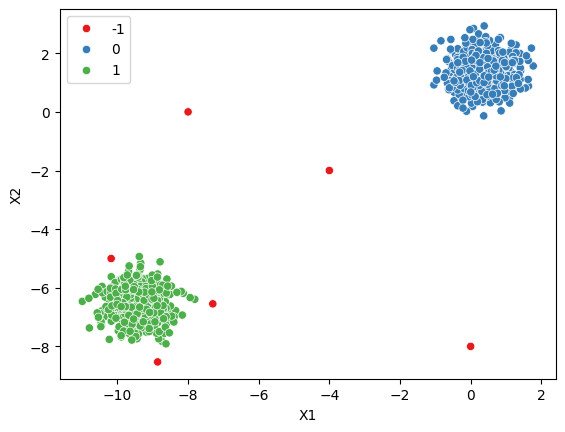

In [55]:
dbscan_many=DBSCAN(eps=0.5)
display_categories(dbscan_many,two_blobs_outliers)

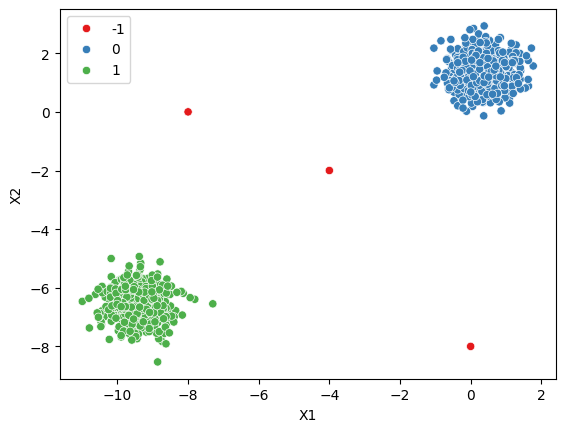

In [56]:
dbscan_3=DBSCAN(eps=0.75)
display_categories(dbscan_3,two_blobs_outliers)

Let's look at the % of outliers, trying to figure out an eps value that homes in the number of outliers 3, at about 1%

Text(0, 0.5, '% Points classified as Outliers')

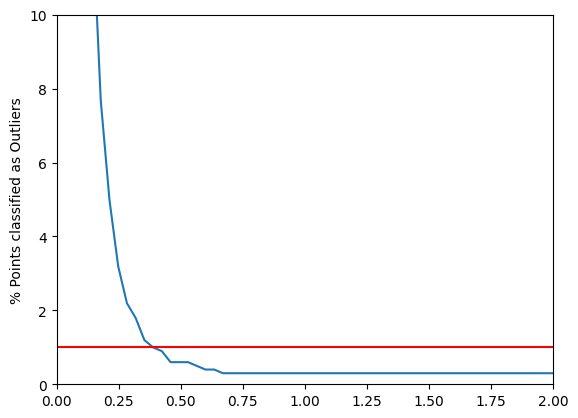

In [57]:
sns.lineplot(x=np.linspace(0.001,7,200),y=outlier_percent)
plt.xlim(0,2)
plt.ylim(0,10)
plt.hlines(y=1,xmin=0,xmax=2,color='red')
plt.ylabel('% Points classified as Outliers')

Now we are going to perform the same method for the min_samples hyperparameter ("minimum samples" within epsilon-distance to be considered a core point).

In [59]:
outlier_percent=[]
number_of_outliers=[]
for n in np.arange(1,100):
    dbscan=DBSCAN(min_samples=n)
    dbscan.fit(two_blobs_outliers)
    number_of_outliers.append(np.sum(dbscan.labels_==-1))
    perc_outliers=100*np.sum(dbscan.labels_==-1)/len(dbscan.labels_)
    outlier_percent.append(perc_outliers)

Text(0, 0.5, '% of points classified as outlier')

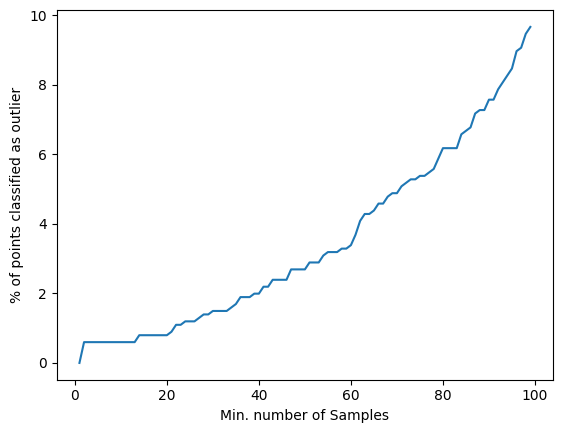

In [60]:
sns.lineplot(x=np.arange(1,100),y=outlier_percent)
plt.xlabel('Min. number of Samples')
plt.ylabel('% of points classified as outlier')

As we increase the number of samples required to be "close enough" for each point to be considered "core point", it also increases the number of points classified as outliers, since it is "more difficult" to become core point.

A good starting point for the min_samples is to start with the double of the dimensions of the dataset. (`2 * data_set.shape[1]`)